In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.4f}'.format)
con = duckdb.connect('C:/Users/kweec/python files/risk-project/notebooks/credit_risk.db')
df = con.execute("SELECT * FROM mart.features").df()



                  id   is_default    loan_amnt     int_rate  installment  \
count   1344976.0000 1344976.0000 1344976.0000 1344976.0000 1344976.0000   
mean   56329030.4389       0.1997   14419.1772       0.1324     438.0564   
min       54734.0000       0.0000     500.0000       0.0531       4.9300   
25%    20007530.5000       0.0000    8000.0000       0.0975     248.4800   
50%    57732365.5000       0.0000   12000.0000       0.1274     375.3800   
75%    84534410.5000       0.0000   20000.0000       0.1599     580.7300   
max   145636374.0000       1.0000   40000.0000       0.3099    1719.8300   
std    38351795.8478       0.3997    8716.3537       0.0477     261.4974   

         annual_inc          dti     fico_avg     open_acc   revol_util  \
count  1344976.0000 1344976.0000 1344976.0000 1344976.0000 1344120.0000   
mean     76268.7771      18.2826     698.1824      11.5941      51.8109   
min         16.0000      -1.0000     627.0000       0.0000       0.0000   
25%      45895.

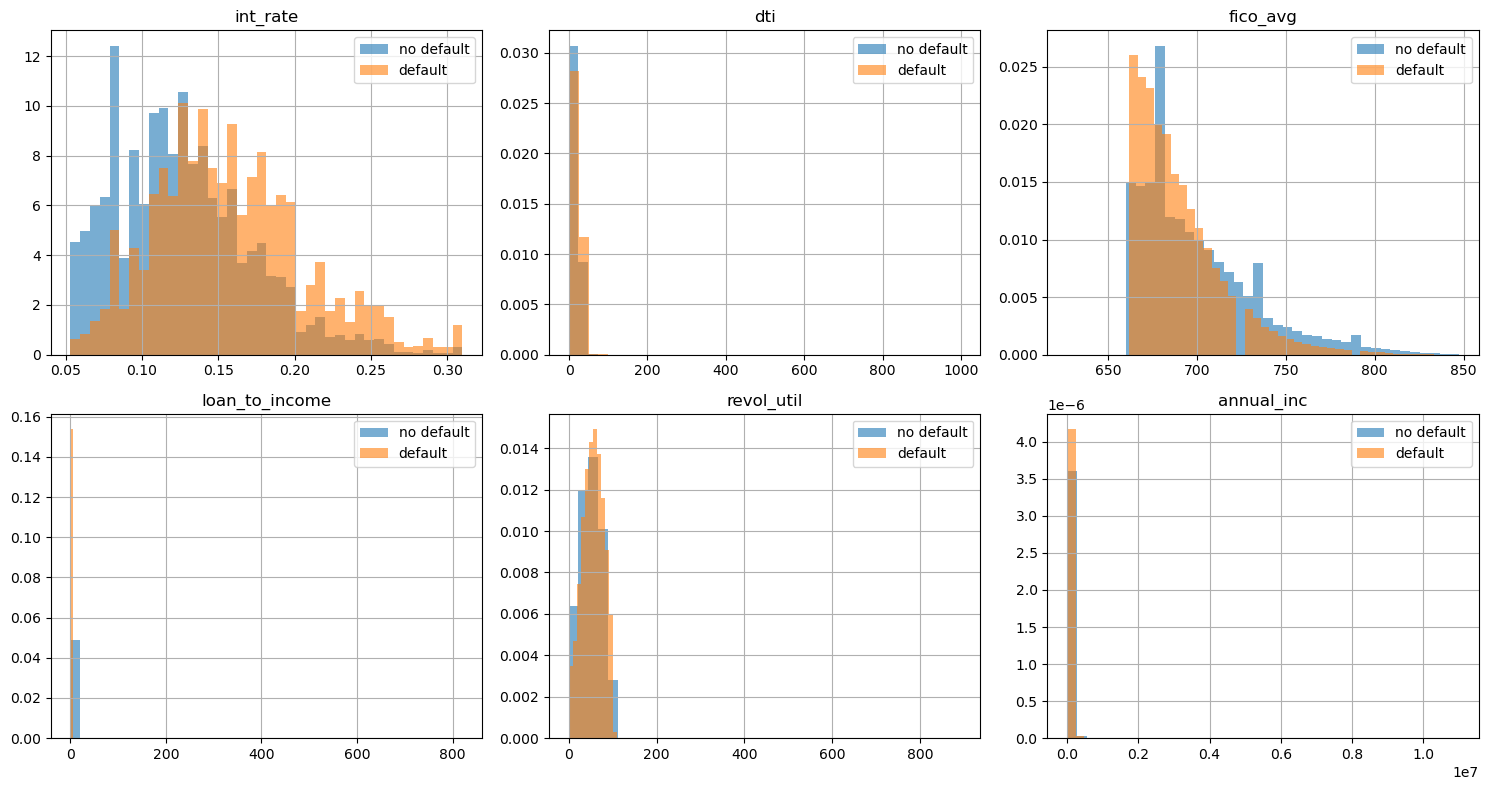

In [5]:
# 1. Базовая статистика
print(df.describe())

# 2. Распределение PD по ключевым фичам
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['int_rate', 'dti', 'fico_avg', 
            'loan_to_income', 'revol_util', 'annual_inc']

for ax, feat in zip(axes.flat, features):
    df.groupby('is_default')[feat].hist(
        bins=40, alpha=0.6, ax=ax, density=True
    )
    ax.set_title(feat)
    ax.legend(['no default', 'default'])

plt.tight_layout()
plt.show()

In [6]:
# 3. Дефолтность по категориям
for col in ['home_ownership', 'purpose', 'term']:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)['is_default']
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
        .round(3)
    )

# 4. Корреляция с таргетом
print("\nКорреляция фич с is_default:")
print(
    df[features + ['is_default']]
    .corr()['is_default']
    .sort_values(ascending=False)
    .round(3)
)


--- home_ownership ---
                 mean   count
home_ownership               
RENT           0.2320  534337
OWN            0.2060  144806
ANY            0.1960     286
OTHER          0.1880     144
MORTGAGE       0.1720  665355
NONE           0.1460      48

--- purpose ---
                     mean   count
purpose                          
small_business     0.2970   15414
renewable_energy   0.2370     933
moving             0.2340    9474
house              0.2190    7251
medical            0.2180   15550
debt_consolidation 0.2110  780127
other              0.2100   77845
vacation           0.1920    9064
major_purchase     0.1860   29422
home_improvement   0.1770   87473
educational        0.1720     326
credit_card        0.1690  295217
car                0.1470   14586
wedding            0.1220    2294

--- term ---
            mean    count
term                     
60 months 0.3250   324439
36 months 0.1600  1020537

Корреляция фич с is_default:
is_default        1.0000
in